### Import libraries

This cell imports pandas for reading and working with tabular data, and NumPy for numerical operations and missing-value handling.

In [28]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 1. Imports and configuration

This cell documents the notebook configuration. The paths identify the four raw datasets, and the sentinel values identify codes that should become missing values.

In [29]:
from pathlib import Path

DATA_DIR = Path('../data')
MISSING_VALUES = [-666666666, -6666666666]
ZIP_PATTERN = r'\d{5}'

DATASETS = {
    'public_features': DATA_DIR / 'miami_dade_public_features.csv',
    'area_features': DATA_DIR / 'area_features.csv',
    'area_options': DATA_DIR / 'area_options.csv',
    'crowd_text_snippets': DATA_DIR / 'crowd_text_snippets.csv',
}

## 2. Reusable functions

These functions keep the cleaning rules consistent across datasets. ZIP codes are handled as strings, missing sentinel values are converted to `NaN`, summary values are extracted only from their labels, and categorical fields are one-hot encoded.

In [30]:
def load_dataset(path):
    """Load a CSV while preserving ZIP codes as strings."""
    return pd.read_csv(path, dtype={'zip': 'string'})

'''
replace_missing_values()- replace all the missing values( -6666666)  into NaN across 4 dataset
'''
def replace_missing_values(df, missing_values=MISSING_VALUES):
    """Replace configured sentinel values with pandas missing values."""
    return df.replace(missing_values, np.nan)


def profile_dataframe(df):
    """Create a column-level profiling table for a DataFrame."""
    profile_rows = []

    for column in df.columns:
        series = df[column]
        numeric_series = pd.to_numeric(series, errors='coerce')
        is_numeric = pd.api.types.is_numeric_dtype(series)

        profile_rows.append({
            'column': column,
            'dtype': str(series.dtype),
            'missing_count': int(series.isna().sum()),
            'zero_count': int((numeric_series == 0).sum()) if is_numeric else np.nan,
            'unique_count': int(series.nunique(dropna=True)),
            'skewness': series.skew() if is_numeric else np.nan,
            'minimum': series.min() if is_numeric else np.nan,
            'maximum': series.max() if is_numeric else np.nan,
            'negative_count': int((numeric_series < 0).sum()) if is_numeric else np.nan,
        })

    return pd.DataFrame(profile_rows).set_index('column')


def plot_numeric_distributions(df, identifier_columns=None, columns_per_row=2):
    """Plot histograms and boxplots for numeric non-identifier columns."""
    identifier_columns = set(identifier_columns or [])
    numeric_columns = [
        column for column in df.select_dtypes(include='number').columns
        if column not in identifier_columns
    ]

    if not numeric_columns:
        print('No numeric non-identifier columns available for plotting.')
        return

    rows = int(np.ceil(len(numeric_columns) / columns_per_row))
    figure, axes = plt.subplots(
        rows * 2,
        columns_per_row,
        figsize=(12, rows * 6),
        squeeze=False,
    )

    for index, column in enumerate(numeric_columns):
        row = (index // columns_per_row) * 2
        column_index = index % columns_per_row
        values = df[column].dropna()

        sns.histplot(values, kde=values.nunique() > 1, ax=axes[row, column_index])
        axes[row, column_index].set_title(f'{column}: histogram')
        axes[row, column_index].set_xlabel(column)

        sns.boxplot(x=values, ax=axes[row + 1, column_index])
        axes[row + 1, column_index].set_title(f'{column}: boxplot')
        axes[row + 1, column_index].set_xlabel(column)

    for unused_index in range(len(numeric_columns), rows * columns_per_row):
        row = (unused_index // columns_per_row) * 2
        column_index = unused_index % columns_per_row
        axes[row, column_index].set_visible(False)
        axes[row + 1, column_index].set_visible(False)

    figure.tight_layout()
    plt.show()


def extract_migration_score(text):
    """Extract a labeled migration score, returning 0 when unavailable."""
    if pd.isna(text):
        return 0.0

    match = re.search(
        r'migration\s+score\s*[:=]?\s*(-?\d+(?:\.\d+)?)',
        str(text),
        flags=re.IGNORECASE,
    )
    if match is None:
        return 0.0

    try:
        return round(float(match.group(1)), 2)
    except ValueError:
        return 0.0


def extract_median_rent(text):
    """Extract a labeled median rent as an integer, returning 0 when unavailable."""
    if pd.isna(text):
        return 0

    match = re.search(
        r'median\s+rent\s*[:=]?\s*~?\s*\$?\s*([\d,]+(?:\.\d+)?)',
        str(text),
        flags=re.IGNORECASE,
    )
    if match is None:
        return 0

    try:
        return int(float(match.group(1).replace(',', '')))
    except ValueError:
        return 0


def add_summary_numeric_columns(df, summary_column='summary'):
    """Add summary-derived numeric columns without overwriting existing columns."""
    result = df.copy()
    audit = {
        'migration_score_missing_or_invalid': 0,
        'median_rent_missing_or_invalid': 0,
        'migration_score_existing': 'migration_score' in result.columns,
        'median_rent_existing': 'median_rent' in result.columns,
    }

    if summary_column not in result.columns:
        raise KeyError(f'Missing required summary column: {summary_column}')

    if 'migration_score' not in result.columns:
        migration_values = result[summary_column].map(extract_migration_score)
        audit['migration_score_missing_or_invalid'] = int((migration_values == 0).sum())
        result['migration_score'] = migration_values.astype(float).round(2)

    if 'median_rent' not in result.columns:
        rent_values = result[summary_column].map(extract_median_rent)
        audit['median_rent_missing_or_invalid'] = int((rent_values == 0).sum())
        result['median_rent'] = rent_values.astype(int)

    return result, audit

'''
drop_columns_by_dataset()- drop dataset-specific columns.

'\miami_dade_public_features.csv'
NAME

'\area_features.csv'
area_name

'\area_options.csv'
Disclaimer

'\crowd_text_snippets.csv'
Source
'''
def drop_columns_by_dataset(datasets, columns_to_drop):
    """Drop configured columns using case-insensitive name matching."""
    cleaned_datasets = {}
    dropped_columns = {}
    missing_columns = {}

    for name, dataset in datasets.items():
        requested_columns = columns_to_drop.get(name, [])
        column_lookup = {column.casefold(): column for column in dataset.columns}
        existing_columns = [
            column_lookup[column.casefold()]
            for column in requested_columns
            if column.casefold() in column_lookup
        ]
        missing_columns[name] = [
            column for column in requested_columns
            if column.casefold() not in column_lookup
        ]
        cleaned_datasets[name] = dataset.drop(columns=existing_columns)
        dropped_columns[name] = existing_columns

    return cleaned_datasets, dropped_columns, missing_columns

'''
drop_rows_with_excessive_missing_values()- Drop row with more than 3 NaN 
'''
def drop_rows_with_excessive_missing_values(df, max_missing=3):
    """Drop rows with more than max_missing NaN values."""
    missing_counts = df.isna().sum(axis=1)
    keep_rows = missing_counts <= max_missing
    return df.loc[keep_rows].copy(), missing_counts

'''
validate_zip_codes()- ensure zip code are all 5 digit and is not empty, else drop the row
'''
def validate_zip_codes(df, zip_column='zip'):
    """Keep rows whose ZIP value is present and exactly five digits."""
    cleaned_df = df.copy()
    zip_values = cleaned_df[zip_column].astype('string').str.strip()
    valid_zip = zip_values.notna() & zip_values.str.fullmatch(ZIP_PATTERN).fillna(False)
    cleaned_df[zip_column] = zip_values
    return cleaned_df.loc[valid_zip].copy()

'''
one_hot_encode()- one hot encode string columns
rent_band
housing_preference
household
theme

'''
def one_hot_encode(df, columns):
    """One-hot encode selected categorical columns and remove their originals."""
    existing_columns = [column for column in columns if column in df.columns]
    return pd.get_dummies(df, columns=existing_columns, dtype=int)

'''
one_hot_encode_tags()- one hot encode string columns with tags
tags
'''
def one_hot_encode_tags(df, column='tags'):
    """Split comma-separated tags and create one binary column per tag."""
    if column not in df.columns:
        return df.copy()

    tags = df[column].fillna('').astype('string').str.get_dummies(sep=',')
    tags.columns = [f'tag_{tag.strip()}' for tag in tags.columns]
    tags = tags.loc[:, tags.columns != 'tag_']
    return pd.concat([df.drop(columns=[column]), tags], axis=1)

<>:143: SyntaxWarning: invalid escape sequence '\m'
<>:143: SyntaxWarning: invalid escape sequence '\m'
/var/folders/zt/0c46hq3s317cq_09dx9btg600000gn/T/ipykernel_10391/1700916929.py:143: SyntaxWarning: invalid escape sequence '\m'
  '''


# Replace misiing value with mean value 

For the following column with NaN in miami_dade_public_features

B01003_001E
B25064_001E
B25077_001E
B07003_001E
B07003_004E
B07003_008E
B07003_010E
B11016_001E
B25003_002E
B25003_003E
zillow_home_value_index
zillow_rent_index

repalce with mean values


In [31]:
def fill_missing_numeric_with_mean(df, columns):
    """Fill selected numeric NaN values with each column's mean."""
    result = df.copy()
    audit_rows = []
    missing_columns = []

    for column in columns:
        if column not in result.columns:
            missing_columns.append(column)
            continue

        missing_before = int(result[column].isna().sum())
        mean_value = result[column].mean()

        if pd.isna(mean_value):
            missing_columns.append(column)
            missing_after = missing_before
        else:
            result[column] = result[column].fillna(mean_value)
            missing_after = int(result[column].isna().sum())

        audit_rows.append({
            'column': column,
            'missing_before': missing_before,
            'mean_used': mean_value,
            'missing_after': missing_after,
        })

    audit = pd.DataFrame(audit_rows)
    return result, audit, missing_columns

## 3. Load all four datasets

This cell loads the public features, area features, area options, and crowd text datasets. The reusable loader preserves the `zip` column as text so leading zeroes are not lost.

In [32]:
datasets = {
    name: load_dataset(path)
    for name, path in DATASETS.items()
}

public_features = datasets['public_features']
area_features = datasets['area_features']
area_options = datasets['area_options']
crowd_text_snippets = datasets['crowd_text_snippets']

## 4. Display original shapes and schemas

This cell records each dataset's size, column names, and data types before cleaning. This gives us a baseline for comparing the cleaned outputs.

In [33]:
original_shapes = {}

for name, dataset in datasets.items():
    original_shapes[name] = dataset.shape
    print(f'\n{name}: shape={dataset.shape}')
    print('columns:', dataset.columns.tolist())
    print(dataset.dtypes)


public_features: shape=(80, 17)
columns: ['NAME', 'B01003_001E', 'B25064_001E', 'B25077_001E', 'B07003_001E', 'B07003_004E', 'B07003_008E', 'B07003_010E', 'B11016_001E', 'B25003_002E', 'B25003_003E', 'zip', 'moved_different_house_pct', 'median_rent_usd', 'population', 'zillow_home_value_index', 'zillow_rent_index']
NAME                                 object
B01003_001E                           int64
B25064_001E                           int64
B25077_001E                           int64
B07003_001E                           int64
B07003_004E                           int64
B07003_008E                           int64
B07003_010E                           int64
B11016_001E                           int64
B25003_002E                           int64
B25003_003E                           int64
zip                          string[python]
moved_different_house_pct           float64
median_rent_usd                       int64
population                            int64
zillow_home_value_inde

## 5. Replace missing sentinel values

This cell applies the same reusable missing-value function to all four datasets. Both sentinel spellings are handled, and the replacement counts are printed for auditing.

In [34]:
sentinel_counts = {}

for name, dataset in datasets.items():
    sentinel_mask = dataset.isin(MISSING_VALUES)
    sentinel_counts[name] = int(sentinel_mask.to_numpy().sum())
    datasets[name] = replace_missing_values(dataset)
    print(f'{name}: replaced {sentinel_counts[name]} sentinel values')

public_features = datasets['public_features']
area_features = datasets['area_features']
area_options = datasets['area_options']
crowd_text_snippets = datasets['crowd_text_snippets']

public_features: replaced 8 sentinel values
area_features: replaced 3 sentinel values
area_options: replaced 0 sentinel values
crowd_text_snippets: replaced 0 sentinel values


## 6. Fill missing public-feature values with column means

This cell fills `NaN` values only in the selected numeric columns of `public_features`. Each column uses its own mean, while existing values and legitimate zeroes are preserved. The audit table records the mean used and missing-value counts before and after imputation.

In [35]:
PUBLIC_NUMERIC_COLUMNS = [
    'B01003_001E',
    'B25064_001E',
    'B25077_001E',
    'B07003_001E',
    'B07003_004E',
    'B07003_008E',
    'B07003_010E',
    'B11016_001E',
    'B25003_002E',
    'B25003_003E',
    'zillow_home_value_index',
    'zillow_rent_index',
]

public_features, public_mean_audit, unavailable_public_columns = fill_missing_numeric_with_mean(
    public_features,
    PUBLIC_NUMERIC_COLUMNS,
)
datasets['public_features'] = public_features

print('Public-feature mean-imputation audit:')
display(public_mean_audit)
if unavailable_public_columns:
    print('Columns missing or entirely NaN:', unavailable_public_columns)

Public-feature mean-imputation audit:


,column,missing_before,mean_used,missing_after
0,B01003_001E,0,33602.962500,0
1,B25064_001E,3,1755.233766,0
2,B25077_001E,2,467974.371795,0
3,B07003_001E,0,33263.850000,0
4,B07003_004E,0,29323.687500,0
5,B07003_008E,0,1339.925000,0
6,B07003_010E,0,314.337500,0
7,B11016_001E,0,11908.500000,0
8,B25003_002E,0,6176.762500,0
9,B25003_003E,0,5731.737500,0


## 6. Extract migration score and median rent from area_options

This cell extracts labeled values from `area_options.summary` before any dataset-specific columns are removed. Missing or malformed values become numeric zero, and existing target columns are preserved rather than overwritten.

In [36]:
area_options, summary_extraction_audit = add_summary_numeric_columns(
    area_options,
    summary_column='summary',
)

datasets['area_options'] = area_options

print('Summary extraction audit:')
print(summary_extraction_audit)
print(area_options[['summary', 'migration_score', 'median_rent']].head())

Summary extraction audit:
{'migration_score_missing_or_invalid': 6, 'median_rent_missing_or_invalid': 0, 'migration_score_existing': False, 'median_rent_existing': False}
                                             summary  migration_score  \
0  Wynwood (ZIP 33127) — your own apartment (e.g....              0.0   
1  Downtown Miami (ZIP 33128) — your own apartmen...              0.0   
2  Brickell (ZIP 33130) — your own apartment with...              0.0   
3  Wynwood (ZIP 33127) — your own studio or 1BR, ...              0.0   
4  Downtown Miami (ZIP 33128) — co-living option ...              0.0   

   median_rent  
0         1283  
1         1191  
2         1553  
3         1283  
4         1191  


## 8. Drop dataset-specific columns

This cell removes the remaining columns that are not needed for the cleaned datasets. Missing requested columns are reported instead of causing an error.

In [37]:
columns_to_drop = {
    'public_features': ['NAME'],
    'area_features': ['area_name'],
    'area_options': ['Disclaimer','option_id','summary'],
    'crowd_text_snippets': ['Source','snippet_id','text'],
}

datasets, dropped_columns, missing_columns = drop_columns_by_dataset(
    datasets,
    columns_to_drop,
)

for name in datasets:
    print(f'{name}: dropped columns={dropped_columns[name]}')
    if missing_columns[name]:
        print(f'{name}: requested columns not found={missing_columns[name]}')

public_features = datasets['public_features']
area_features = datasets['area_features']
area_options = datasets['area_options']
crowd_text_snippets = datasets['crowd_text_snippets']

public_features: dropped columns=['NAME']
area_features: dropped columns=['area_name']
area_options: dropped columns=['disclaimer', 'option_id', 'summary']
crowd_text_snippets: dropped columns=['source', 'snippet_id', 'text']


## 9. Drop rows with too many missing values

Rows with more than three `NaN` values are removed after summary extraction and column removal. Rows with exactly three missing values remain.

In [38]:
missing_row_counts = {}

for name, dataset in datasets.items():
    cleaned_dataset, missing_counts = drop_rows_with_excessive_missing_values(
        dataset,
        max_missing=3,
    )
    missing_row_counts[name] = {
        'before': len(dataset),
        'after': len(cleaned_dataset),
        'dropped': len(dataset) - len(cleaned_dataset),
    }
    datasets[name] = cleaned_dataset
    print(f'{name}: dropped {missing_row_counts[name]["dropped"]} rows')

public_features = datasets['public_features']
area_features = datasets['area_features']
area_options = datasets['area_options']
crowd_text_snippets = datasets['crowd_text_snippets']

public_features: dropped 0 rows
area_features: dropped 0 rows
area_options: dropped 0 rows
crowd_text_snippets: dropped 0 rows


## 10. Validate ZIP columns

This cell applies the reusable ZIP validation function after summary extraction, column removal, and missing-row cleaning. Rows with an empty, missing, or non-five-digit ZIP are removed and counted.

In [39]:
zip_validation_counts = {}

for name, dataset in datasets.items():
    validated_dataset = validate_zip_codes(dataset)
    zip_validation_counts[name] = {
        'before': len(dataset),
        'after': len(validated_dataset),
        'dropped': len(dataset) - len(validated_dataset),
    }
    datasets[name] = validated_dataset
    print(f'{name}: kept {len(validated_dataset)} of {len(dataset)} rows')

public_features = datasets['public_features']
area_features = datasets['area_features']
area_options = datasets['area_options']
crowd_text_snippets = datasets['crowd_text_snippets']

public_features: kept 80 of 80 rows
area_features: kept 80 of 80 rows
area_options: kept 10 of 10 rows
crowd_text_snippets: kept 20 of 20 rows


## 11. Apply one-hot encoding

This cell encodes categorical columns while leaving identifiers, ZIP codes, numeric summary values, and free text unchanged. Tags are split into separate binary columns because one row can contain multiple tags.

In [40]:
area_features = one_hot_encode(area_features, ['rent_band'])
area_options = one_hot_encode(area_options, ['rent_band', 'housing_preference', 'household'])
area_options = one_hot_encode_tags(area_options, 'tags')
crowd_text_snippets = one_hot_encode(crowd_text_snippets, ['theme'])

datasets.update({
    'public_features': public_features,
    'area_features': area_features,
    'area_options': area_options,
    'crowd_text_snippets': crowd_text_snippets,
})

for name, dataset in datasets.items():
    print(f'\n{name} after one-hot encoding:')
    print(dataset.head())
    print('columns:', dataset.columns.tolist())


public_features after one-hot encoding:
   B01003_001E  B25064_001E   B25077_001E  B07003_001E  B07003_004E  \
0            0  1755.233766  4.679744e+05            0            0   
1          792  1755.233766  2.000001e+06          792          630   
2         1873  2370.000000  1.335900e+06         1824          962   
3        54873  1238.000000  3.393000e+05        54290        49530   
4        46798  1546.000000  2.871000e+05        46403        41635   

   B07003_008E  B07003_010E  B11016_001E  B25003_002E  B25003_003E    zip  \
0            0            0            0            0            0  33101   
1           97            0          328          307           21  33109   
2          241            8          816           76          740  33122   
3         2057          171        21227         5080        16147  33125   
4         1763          240        18073         7104        10969  33126   

   moved_different_house_pct  median_rent_usd  population  \
0       

## 14. Profile public_features distributions

This section profiles only `miami_dade_public_features.csv` after the requested mean imputation. It reports all-column descriptive statistics, missing and zero counts, skewness, unique values, dtypes, minimums, maximums, and negative-value flags before any decision about normalization, transformation, or winsorization.

In [41]:
describe_public_features = public_features.describe(include='all').T
public_feature_profile = profile_dataframe(public_features)

print('public_features.describe(include="all").T:')
display(describe_public_features)

print('public_features column profile:')
display(public_feature_profile)

negative_value_flags = public_feature_profile.loc[
    public_feature_profile['negative_count'].fillna(0) > 0,
    ['dtype', 'negative_count', 'minimum', 'maximum'],
]

print('Negative-value flags:')
if negative_value_flags.empty:
    print('No negative values found in public_features.')
else:
    display(negative_value_flags)

print('Skewness flags (absolute skewness > 1):')
display(public_feature_profile.loc[
    public_feature_profile['skewness'].abs() > 1,
    ['dtype', 'skewness'],
])

public_features.describe(include="all").T:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
B01003_001E,80.0,NaN,NaN,NaN,33602.9625,17804.783671,0.0,20282.25,32913.5,46864.75,71088.0
B25064_001E,80.0,NaN,NaN,NaN,1755.233766,450.842949,1094.0,1477.75,1673.5,1913.5,3501.0
B25077_001E,80.0,NaN,NaN,NaN,467974.371795,279794.328459,195700.0,323350.0,382800.0,467918.592949,2000001.0
B07003_001E,80.0,NaN,NaN,NaN,33263.85,17631.571945,0.0,19795.5,32612.0,46426.75,70409.0
B07003_004E,80.0,NaN,NaN,NaN,29323.6875,16050.435529,0.0,16223.25,28138.0,41851.25,64525.0
B07003_008E,80.0,NaN,NaN,NaN,1339.925,848.830883,0.0,743.5,1214.5,1787.75,4870.0
B07003_010E,80.0,NaN,NaN,NaN,314.3375,265.589287,0.0,122.75,248.5,432.5,1188.0
B11016_001E,80.0,NaN,NaN,NaN,11908.5,6077.870603,0.0,6830.25,11880.0,16742.5,25048.0
B25003_002E,80.0,NaN,NaN,NaN,6176.7625,3728.381568,0.0,3265.25,5674.0,8684.25,15675.0
B25003_003E,80.0,NaN,NaN,NaN,5731.7375,3726.255231,0.0,3186.75,5406.5,7855.75,16147.0


public_features column profile:


,dtype,missing_count,zero_count,unique_count,skewness,minimum,maximum,negative_count
column,,,,,,,,
B01003_001E,int64,0,2.0,79,0.193203,0.000000,7.108800e+04,0.0
B25064_001E,float64,0,0.0,76,1.485348,1094.000000,3.501000e+03,0.0
B25077_001E,float64,0,0.0,79,3.144498,195700.000000,2.000001e+06,0.0
B07003_001E,int64,0,2.0,79,0.191957,0.000000,7.040900e+04,0.0
B07003_004E,int64,0,2.0,79,0.214685,0.000000,6.452500e+04,0.0
B07003_008E,int64,0,2.0,77,1.117399,0.000000,4.870000e+03,0.0
B07003_010E,int64,0,4.0,72,1.247264,0.000000,1.188000e+03,0.0
B11016_001E,int64,0,2.0,79,-0.085598,0.000000,2.504800e+04,0.0
B25003_002E,int64,0,2.0,79,0.409952,0.000000,1.567500e+04,0.0


Negative-value flags:
No negative values found in public_features.
Skewness flags (absolute skewness > 1):


,dtype,skewness
column,,
B25064_001E,float64,1.485348
B25077_001E,float64,3.144498
B07003_008E,int64,1.117399
B07003_010E,int64,1.247264
moved_different_house_pct,float64,2.189283
median_rent_usd,float64,1.458330
zillow_home_value_index,float64,6.691279
zillow_rent_index,float64,4.868116


In [42]:
print(list(public_features))

['B01003_001E', 'B25064_001E', 'B25077_001E', 'B07003_001E', 'B07003_004E', 'B07003_008E', 'B07003_010E', 'B11016_001E', 'B25003_002E', 'B25003_003E', 'zip', 'moved_different_house_pct', 'median_rent_usd', 'population', 'zillow_home_value_index', 'zillow_rent_index']


### Distribution plots

This cell creates a histogram with KDE and a boxplot for each numeric public feature. ZIP is excluded because it is an identifier rather than a measurable feature.

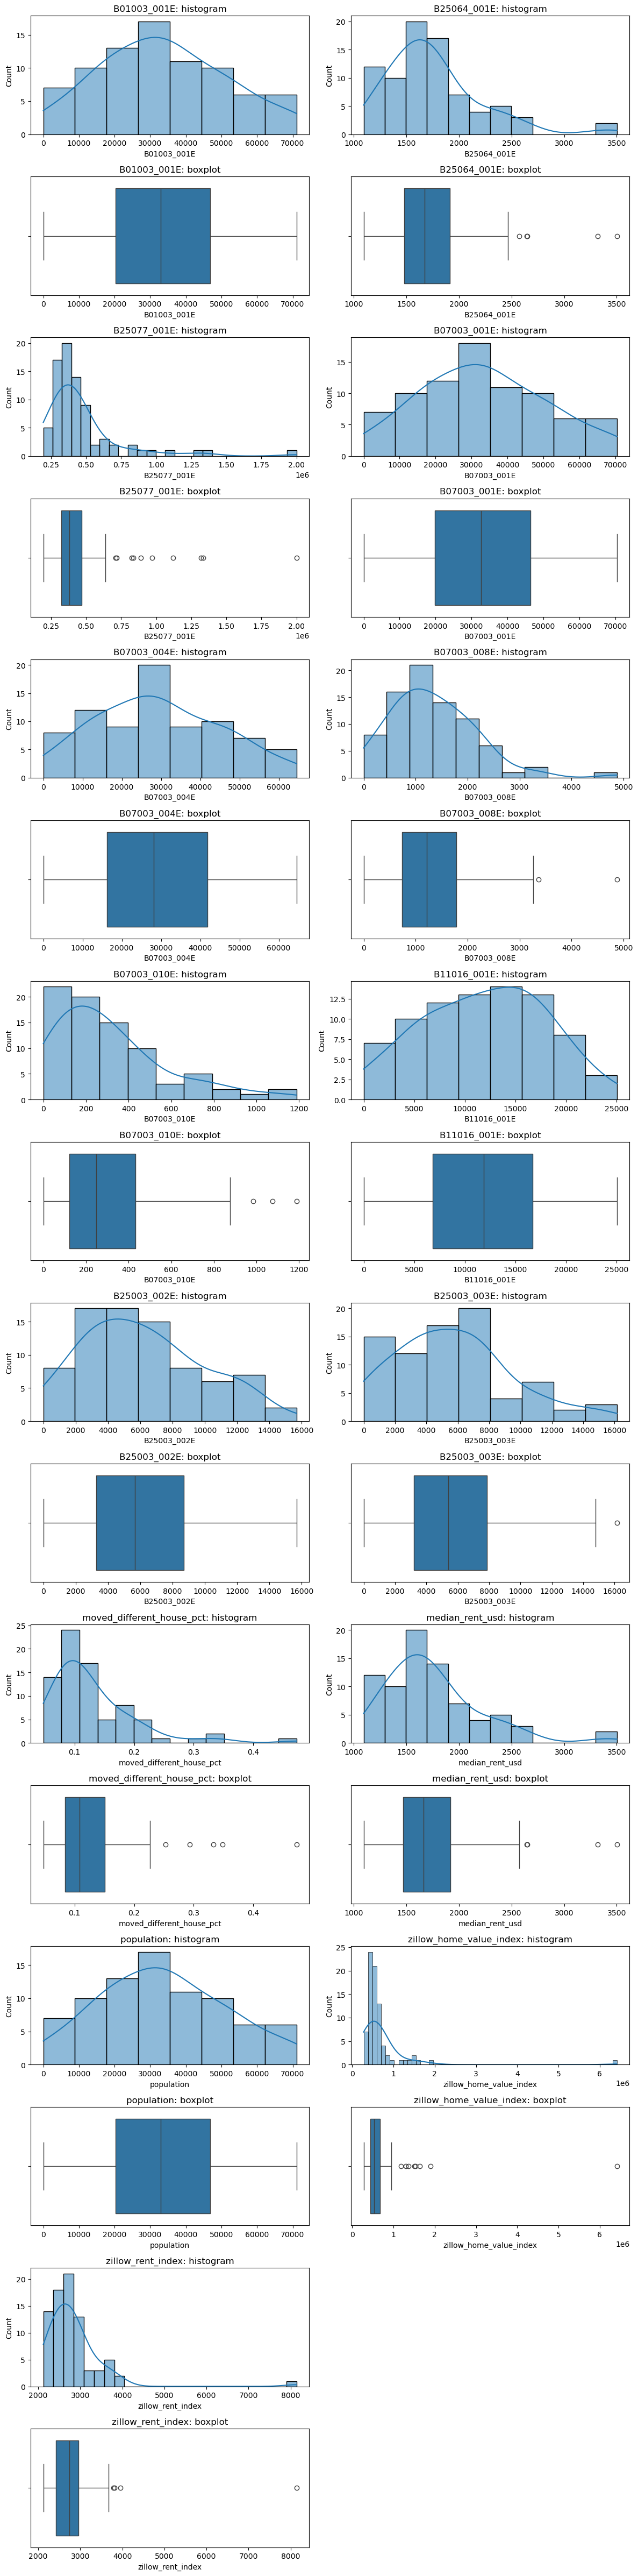

In [43]:
plot_numeric_distributions(
    public_features,
    identifier_columns={'zip'},
)

# Clean columns with more than or equal 4 '0' in miami_data_public_featues

these column shall be remove as they hold nothing 

In [44]:
def drop_rows_with_excessive_zeros(df, max_zeros=3, exclude_columns=None):
    """Drop rows that have more than max_zeros zero values in numeric columns."""
    exclude_columns = set(exclude_columns or [])
    numeric_columns = [
        column for column in df.select_dtypes(include='number').columns
        if column not in exclude_columns
    ]

    zero_counts = (df[numeric_columns] == 0).sum(axis=1)
    keep_rows = zero_counts <= max_zeros
    return df.loc[keep_rows].copy(), zero_counts, numeric_columns


# Drop rows with 4 or more zeros (keep rows with 0-3 zeros)
rows_before = len(public_features)

public_features, public_zero_counts, zero_check_columns = drop_rows_with_excessive_zeros(
    public_features,
    max_zeros=3,
    exclude_columns={'zip'},
)
datasets['public_features'] = public_features

rows_dropped = rows_before - len(public_features)

print(f'Columns checked for zeros: {zero_check_columns}')
print(f'public_features: dropped {rows_dropped} rows with >= 4 zeros '
      f'({rows_before} -> {len(public_features)})')
print('Zero-count distribution before dropping:')
print('Zeros in row | number of rows')
print(public_zero_counts.value_counts().sort_index())


Columns checked for zeros: ['B01003_001E', 'B25064_001E', 'B25077_001E', 'B07003_001E', 'B07003_004E', 'B07003_008E', 'B07003_010E', 'B11016_001E', 'B25003_002E', 'B25003_003E', 'moved_different_house_pct', 'median_rent_usd', 'population', 'zillow_home_value_index', 'zillow_rent_index']
public_features: dropped 2 rows with >= 4 zeros (80 -> 78)
Zero-count distribution before dropping:
Zeros in row | number of rows
0    76
1     2
9     2
Name: count, dtype: int64


# Replace '0' with mean value in miami_data_public_features

in order to reduce outlier , we apply mean value for columns = 0

In [45]:
def replace_zeros_with_mean(df, exclude_columns=None):
    """Replace 0 with each numeric column's mean (calculated from non-zero values)."""
    result = df.copy()
    exclude_columns = set(exclude_columns or [])
    numeric_columns = [
        column for column in result.select_dtypes(include='number').columns
        if column not in exclude_columns
    ]

    audit_rows = []
    for column in numeric_columns:
        zeros_before = int((result[column] == 0).sum())
        mean_value = result.loc[result[column] != 0, column].mean()  # mean without the zeros

        if zeros_before > 0 and pd.notna(mean_value):
            result[column] = result[column].replace(0, mean_value)

        audit_rows.append({
            'column': column,
            'zeros_before': zeros_before,
            'mean_used': mean_value,
            'zeros_after': int((result[column] == 0).sum()),
        })

    return result, pd.DataFrame(audit_rows).set_index('column')

public_features, zero_replacement_audit = replace_zeros_with_mean(
    public_features,
    exclude_columns={'zip'},
)
datasets['public_features'] = public_features

display(zero_replacement_audit[zero_replacement_audit['zeros_before'] > 0])

,zeros_before,mean_used,zeros_after
column,,,
B07003_010E,2,330.881579,0


# Normalization

apply towards miami_dade_public_features.csv

In [46]:
# Calculate the upper 95th-percentile cap from the cleaned public feature column.
# Zillow home value index: upper 95th percentile
zhvi_column = "zillow_home_value_index"
zhvi_winsorized_column = "winsorized_zillow_home_value_index"

zhvi_original = public_features[zhvi_column].copy()
zhvi_cap = zhvi_original.quantile(0.95)

public_features[zhvi_winsorized_column] = zhvi_original.clip(
    upper=zhvi_cap
)

zhvi_values_capped = int((zhvi_original > zhvi_cap).sum())

print(f"Upper 95th-percentile cap: {zhvi_cap:,.2f}")
print(f"Values capped: {zhvi_values_capped}")
print(
    f"Skewness before: {zhvi_original.skew():.3f} "
    f"-> after: {public_features[zhvi_winsorized_column].skew():.3f}"
)

# winsorize zillow rent index

# Zillow rent index: upper 99th percentile
zri_column = "zillow_rent_index"
zri_winsorized_column = "winsorized_zillow_rent_index"

zri_original = public_features[zri_column].copy()
zri_cap = zri_original.quantile(0.99)

public_features[zri_winsorized_column] = zri_original.clip(
    upper=zri_cap
)

zri_values_capped = int((zri_original > zri_cap).sum())

print(f"Upper 99th-percentile cap: {zri_cap:,.2f}")
print(f"Values capped: {zri_values_capped}")

assert zri_values_capped == 1, (
    f"Expected exactly 1 affected row, found {zri_values_capped}"
)

print(
    f"Skewness before: {zri_original.skew():.3f} "
    f"-> after: {public_features[zri_winsorized_column].skew():.3f}"
)

# winsorize moved_different_house_pct

# Moved different house percentage: upper 95th percentile
mdhp_column = "moved_different_house_pct"
mdhp_winsorized_column = "winsorized_moved_different_house_pct"

mdhp_original = public_features[mdhp_column].copy()
mdhp_cap = mdhp_original.quantile(0.95)

public_features[mdhp_winsorized_column] = mdhp_original.clip(
    upper=mdhp_cap
)

mdhp_values_capped = int((mdhp_original > mdhp_cap).sum())

print(f"Upper 95th-percentile cap: {mdhp_cap:,.2f}")
print(f"Values capped: {mdhp_values_capped}")

assert mdhp_values_capped == 4, (
    f"Expected exactly 4 affected rows, found {mdhp_values_capped}"
)

print(
    f"Skewness before: {mdhp_original.skew():.3f} "
    f"-> after: {public_features[mdhp_winsorized_column].skew():.3f}"
)

# winsorize B25077_001E: Median home value (ACS)

# Median home value (ACS): upper 95th percentile
B25077_column = "B25077_001E"
B25077_winsorized_column = "winsorized_B25077_001E"

B25077_original = public_features[B25077_column].copy()
B25077_cap = B25077_original.quantile(0.95)

public_features[B25077_winsorized_column] = B25077_original.clip(
    upper=B25077_cap
)

B25077_values_capped = int((B25077_original > B25077_cap).sum())

print(f"Upper 95th-percentile cap: {B25077_cap:,.2f}")
print(f"Values capped: {B25077_values_capped}")

assert B25077_values_capped == 4, (
    f"Expected exactly 4 affected rows, found {B25077_values_capped}"
)

print(
    f"Skewness before: {B25077_original.skew():.3f} "
    f"-> after: {public_features[B25077_winsorized_column].skew():.3f}"
)

# winsorize B25064_001E: Median gross rent (ACS)

# Median gross rent (ACS): upper 95th percentile
B25064_column = "B25064_001E"
B25064_winsorized_column = "winsorized_B25064_001E"

B25064_original = public_features[B25064_column].copy()
B25064_cap = B25064_original.quantile(0.95)

public_features[B25064_winsorized_column] = B25064_original.clip(
    upper=B25064_cap
)

B25064_values_capped = int((B25064_original > B25064_cap).sum())

print(f"Upper 95th-percentile cap: {B25064_cap:,.2f}")
print(f"Values capped: {B25064_values_capped}")
print(
    f"Skewness before: {B25064_original.skew():.3f} "
    f"-> after: {public_features[B25064_winsorized_column].skew():.3f}"
)

# winsorize B07003_008E: Moved within same county (ACS)

# Moved within same county (ACS): upper 95th percentile
B07003_008E_column = "B07003_008E"
B07003_008E_winsorized_column = "winsorized_B07003_008E"

B07003_008E_original = public_features[B07003_008E_column].copy()
B07003_008E_cap = B07003_008E_original.quantile(0.95)

public_features[B07003_008E_winsorized_column] = B07003_008E_original.clip(
    upper=B07003_008E_cap
)

B07003_008E_values_capped = int(
    (B07003_008E_original > B07003_008E_cap).sum()
)

print(f"Upper 95th-percentile cap: {B07003_008E_cap:,.2f}")
print(f"Values capped: {B07003_008E_values_capped}")
print(
    f"Skewness before: {B07003_008E_original.skew():.3f} "
    f"-> after: {public_features[B07003_008E_winsorized_column].skew():.3f}"
)

Upper 95th-percentile cap: 1,509,147.99
Values capped: 4
Skewness before: 6.610 -> after: 1.907
Upper 99th-percentile cap: 4,912.73
Values capped: 1
Skewness before: 4.809 -> after: 1.475
Upper 95th-percentile cap: 0.26
Values capped: 4
Skewness before: 2.189 -> after: 0.962
Upper 95th-percentile cap: 994,065.00
Values capped: 4
Skewness before: 3.106 -> after: 1.647
Upper 95th-percentile cap: 2,581.65
Values capped: 4
Skewness before: 1.467 -> after: 0.672
Upper 95th-percentile cap: 2,652.30
Values capped: 4
Skewness before: 1.205 -> after: 0.205


## Profile and plot the winsorized Zillow home value index

This section profiles the original and winsorized Zillow home value index after capping values above the 95th percentile.

Descriptive statistics before and after winsorization:


,count,mean,std,min,25%,50%,75%,max
zillow_home_value_index,78.0,689195.052526,727797.402258,277220.965206,443719.755933,527054.073789,668344.670289,6.413596e+06
winsorized_zillow_home_value_index,78.0,619341.957679,306790.676444,277220.965206,443719.755933,527054.073789,668344.670289,1.509148e+06


Detailed profile before and after winsorization:


,dtype,missing_count,zero_count,unique_count,skewness,minimum,maximum,negative_count
column,,,,,,,,
zillow_home_value_index,float64,0,0,78,6.610382,277220.965206,6.413596e+06,0
winsorized_zillow_home_value_index,float64,0,0,75,1.906814,277220.965206,1.509148e+06,0


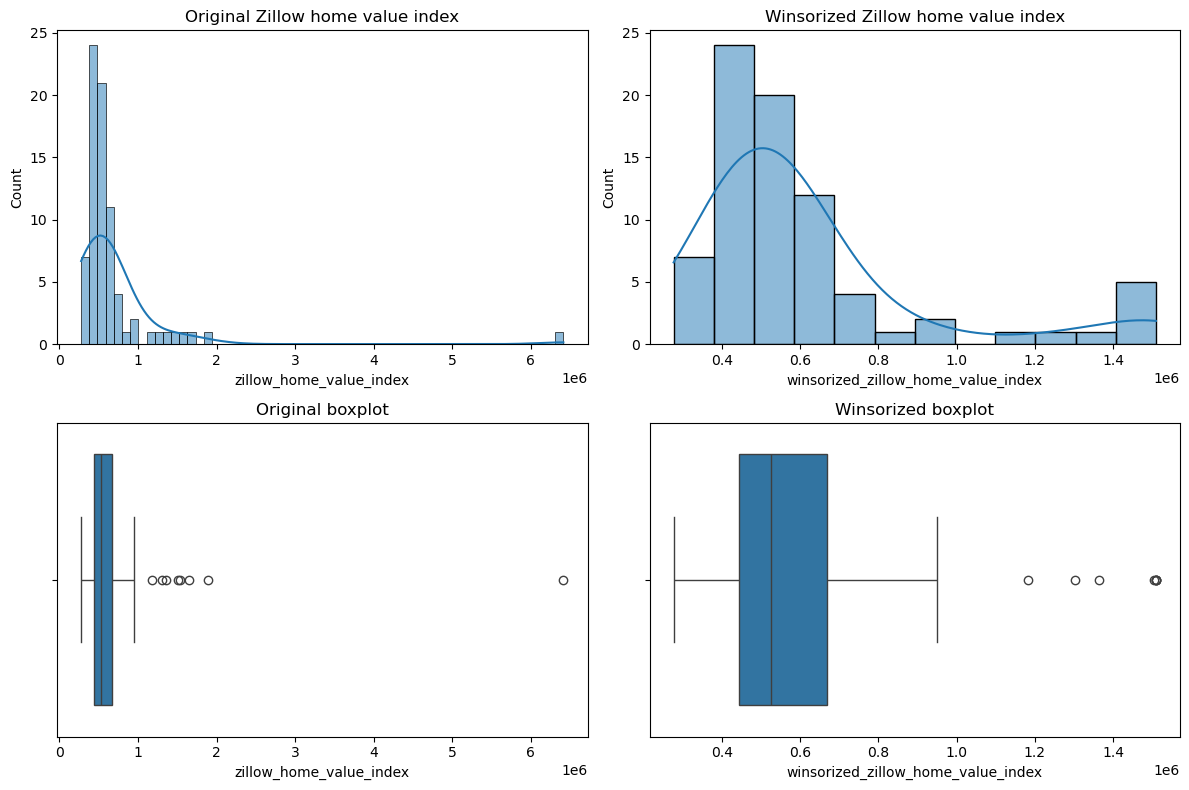

Descriptive statistics before and after winsorization:


,count,mean,std,min,25%,50%,75%,max
zillow_rent_index,78.0,2833.208483,749.955790,2120.972222,2415.719109,2710.059854,2985.161584,8142.963287
winsorized_zillow_rent_index,78.0,2791.795188,500.707515,2120.972222,2415.719109,2710.059854,2985.161584,4912.726249


Detailed profile before and after winsorization:


,dtype,missing_count,zero_count,unique_count,skewness,minimum,maximum,negative_count
column,,,,,,,,
zillow_rent_index,float64,0,0,75,4.809261,2120.972222,8142.963287,0
winsorized_zillow_rent_index,float64,0,0,75,1.474735,2120.972222,4912.726249,0


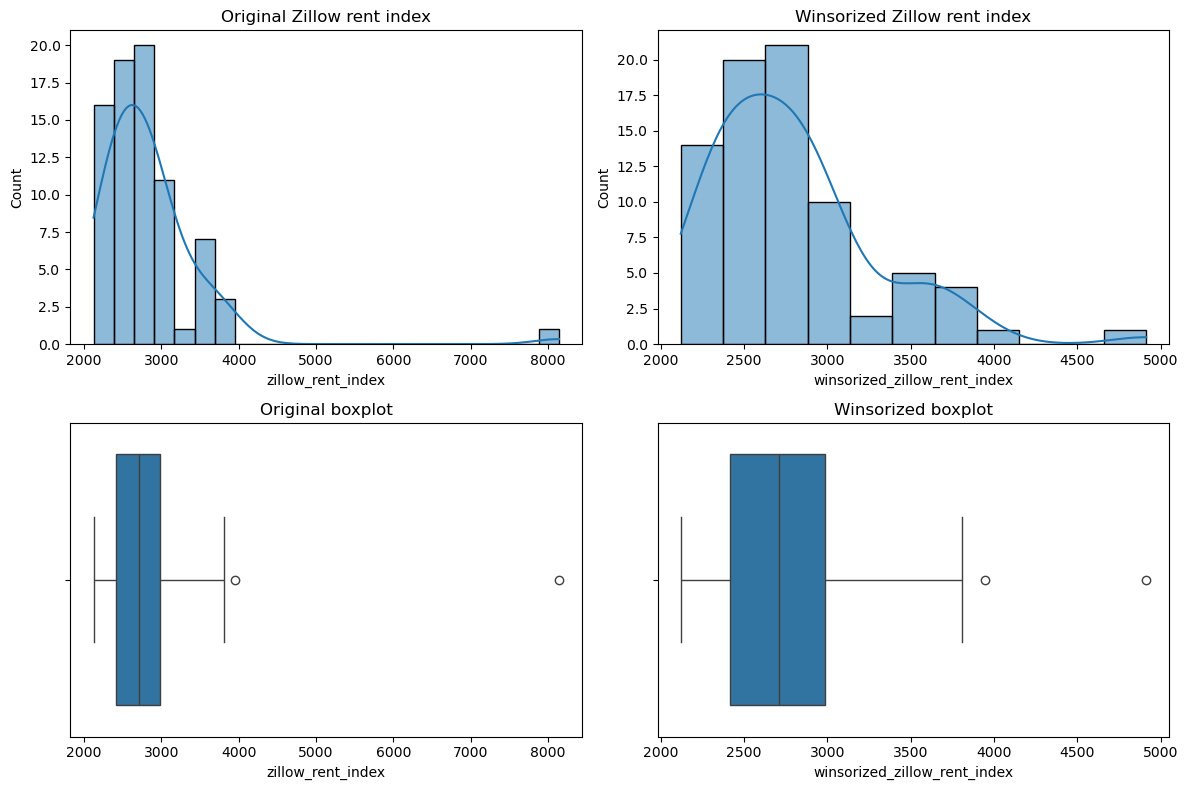

Descriptive statistics before and after winsorization:


,count,mean,std,min,25%,50%,75%,max
moved_different_house_pct,78.0,0.130389,0.072798,0.047588,0.083908,0.108783,0.150853,0.472588
winsorized_moved_different_house_pct,78.0,0.125089,0.055743,0.047588,0.083908,0.108783,0.150853,0.258556


Detailed profile before and after winsorization:


,dtype,missing_count,zero_count,unique_count,skewness,minimum,maximum,negative_count
column,,,,,,,,
moved_different_house_pct,float64,0,0,78,2.189283,0.047588,0.472588,0
winsorized_moved_different_house_pct,float64,0,0,75,0.962295,0.047588,0.258556,0


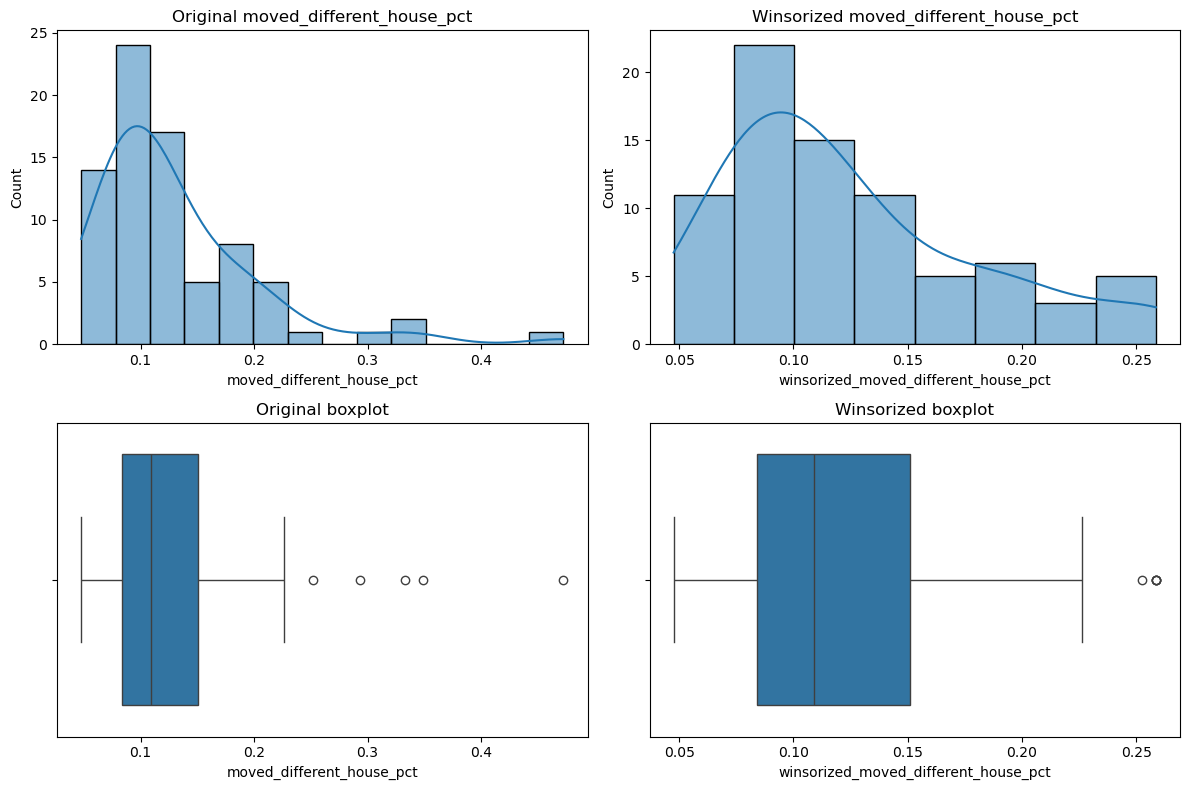

Descriptive statistics before and after winsorization:


,count,mean,std,min,25%,50%,75%,max
B25077_001E,78.0,467974.371795,283404.727178,195700.0,321850.0,380100.0,466100.0,2000001.0
winsorized_B25077_001E,78.0,444898.205128,197309.666585,195700.0,321850.0,380100.0,466100.0,994065.0


Detailed profile before and after winsorization:


,dtype,missing_count,zero_count,unique_count,skewness,minimum,maximum,negative_count
column,,,,,,,,
B25077_001E,float64,0,0,78,3.106481,195700.0,2000001.0,0
winsorized_B25077_001E,float64,0,0,75,1.647134,195700.0,994065.0,0


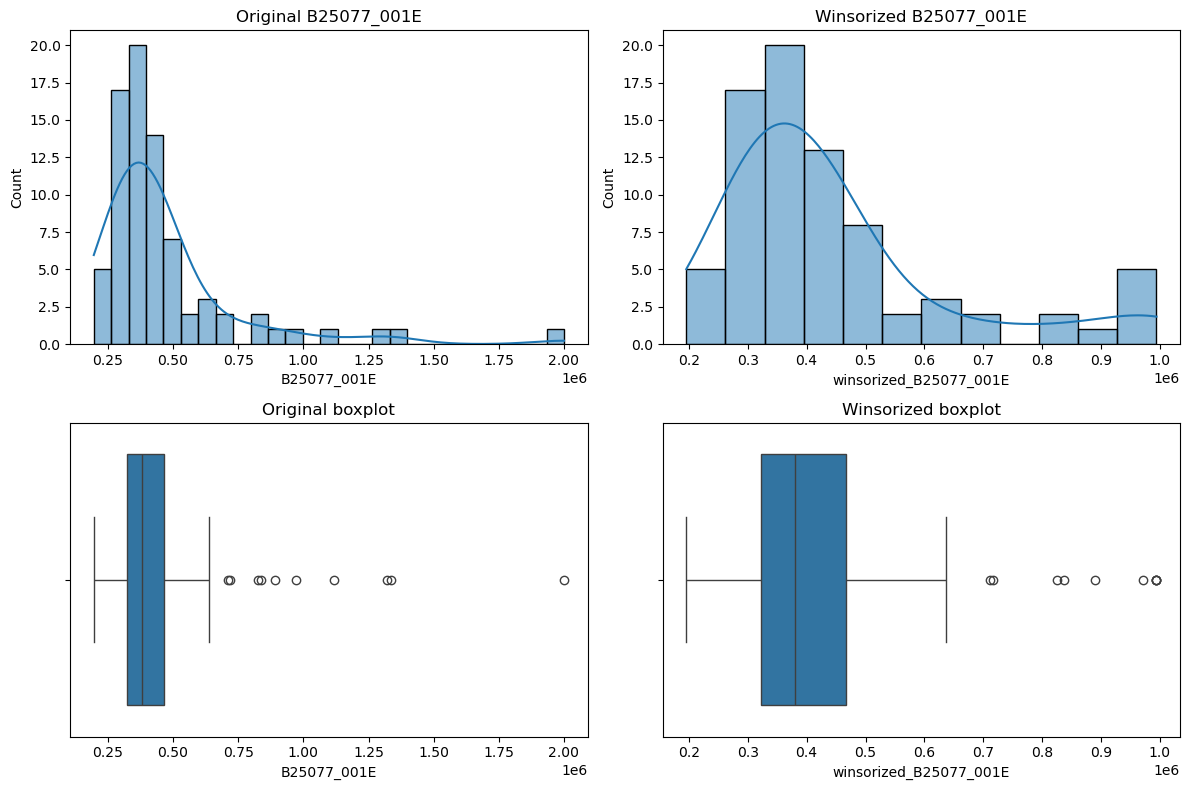

Descriptive statistics before and after winsorization:


,count,mean,std,min,25%,50%,75%,max
B25064_001E,78.0,1755.233766,456.660518,1094.0,1473.25,1665.0,1916.5,3501.00
winsorized_B25064_001E,78.0,1732.331202,389.203912,1094.0,1473.25,1665.0,1916.5,2581.65


Detailed profile before and after winsorization:


,dtype,missing_count,zero_count,unique_count,skewness,minimum,maximum,negative_count
column,,,,,,,,
B25064_001E,float64,0,0,76,1.467391,1094.0,3501.00,0
winsorized_B25064_001E,float64,0,0,73,0.672287,1094.0,2581.65,0


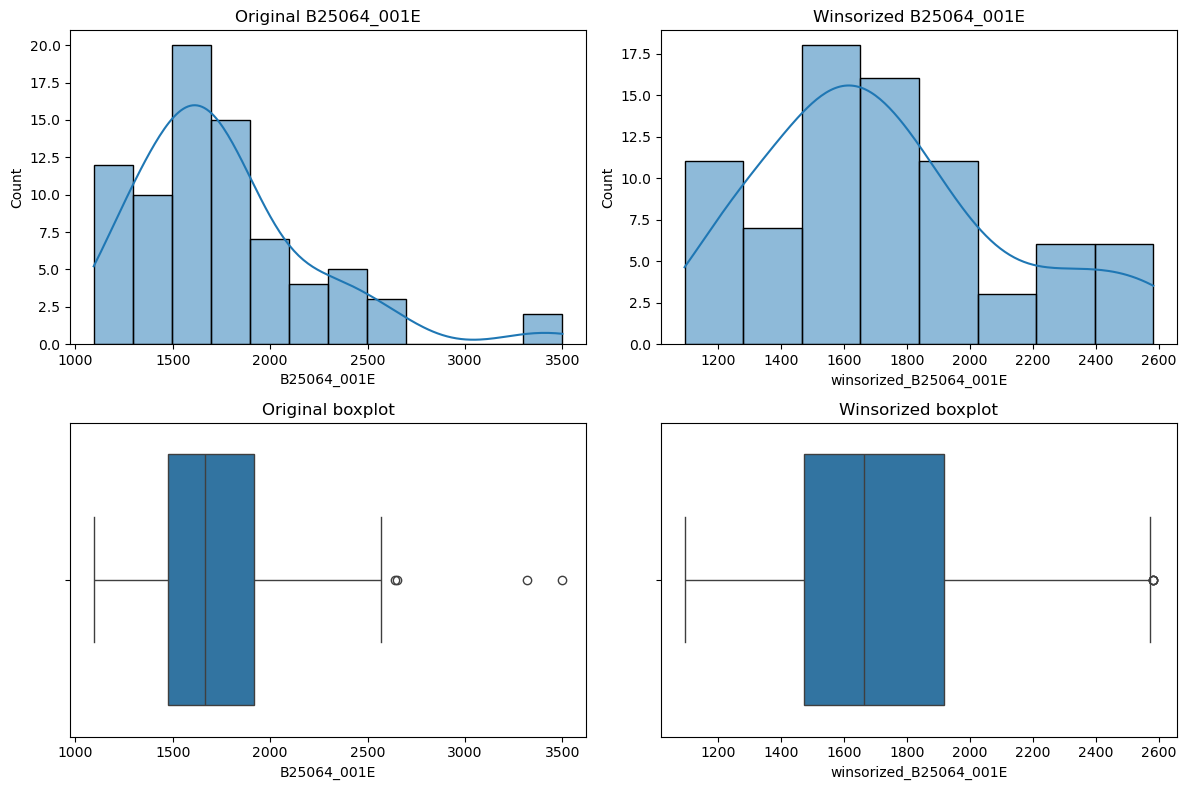

Descriptive statistics before and after winsorization:


,count,mean,std,min,25%,50%,75%,max
B07003_008E,78.0,1374.282051,831.504081,97.0,753.5,1229.0,1809.25,4870.0
winsorized_B07003_008E,78.0,1326.541026,699.857044,97.0,753.5,1229.0,1809.25,2652.3


Detailed profile before and after winsorization:


,dtype,missing_count,zero_count,unique_count,skewness,minimum,maximum,negative_count
column,,,,,,,,
B07003_008E,int64,0,0,76,1.204653,97.0,4870.0,0
winsorized_B07003_008E,float64,0,0,73,0.205487,97.0,2652.3,0


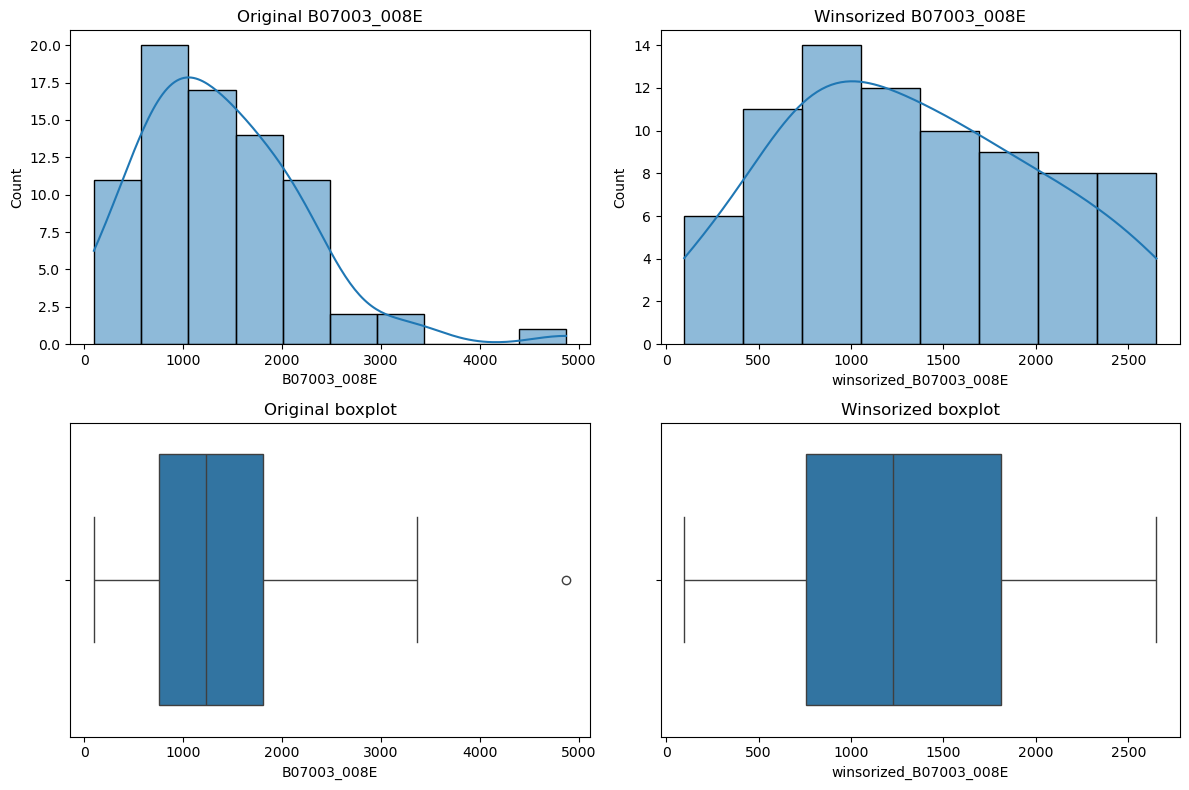

In [47]:
zhvi_comparison = public_features[[
    zhvi_column,
    zhvi_winsorized_column,
]].copy()

print('Descriptive statistics before and after winsorization:')
display(zhvi_comparison.describe().T)

print('Detailed profile before and after winsorization:')
zhvi_profile = profile_dataframe(zhvi_comparison)
display(zhvi_profile)

figure, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(
    public_features[zhvi_column].dropna(),
    kde=True,
    ax=axes[0, 0],
)
axes[0, 0].set_title('Original Zillow home value index')

sns.histplot(
    public_features[zhvi_winsorized_column].dropna(),
    kde=True,
    ax=axes[0, 1],
)
axes[0, 1].set_title('Winsorized Zillow home value index')

sns.boxplot(x=public_features[zhvi_column], ax=axes[1, 0])
axes[1, 0].set_title('Original boxplot')

sns.boxplot(
    x=public_features[zhvi_winsorized_column],
    ax=axes[1, 1],
)
axes[1, 1].set_title('Winsorized boxplot')

figure.tight_layout()
plt.show()

# comparison profile for zillow rent index

zri_comparison = public_features[
    [zri_column, zri_winsorized_column]
].copy()

print("Descriptive statistics before and after winsorization:")
display(zri_comparison.describe().T)

print("Detailed profile before and after winsorization:")
display(profile_dataframe(zri_comparison))

figure, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(public_features[zri_column].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Original Zillow rent index")

sns.histplot(
    public_features[zri_winsorized_column].dropna(),
    kde=True,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Winsorized Zillow rent index")

sns.boxplot(x=public_features[zri_column], ax=axes[1, 0])
axes[1, 0].set_title("Original boxplot")

sns.boxplot(
    x=public_features[zri_winsorized_column],
    ax=axes[1, 1],
)
axes[1, 1].set_title("Winsorized boxplot")

figure.tight_layout()
plt.show()

# comparison profile for moved_different_house_pct

mdhp_comparison = public_features[
    [mdhp_column, mdhp_winsorized_column]
].copy()

print("Descriptive statistics before and after winsorization:")
display(mdhp_comparison.describe().T)

print("Detailed profile before and after winsorization:")
display(profile_dataframe(mdhp_comparison))

figure, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(public_features[mdhp_column].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Original moved_different_house_pct")

sns.histplot(
    public_features[mdhp_winsorized_column].dropna(),
    kde=True,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Winsorized moved_different_house_pct")

sns.boxplot(x=public_features[mdhp_column], ax=axes[1, 0])
axes[1, 0].set_title("Original boxplot")

sns.boxplot(
    x=public_features[mdhp_winsorized_column],
    ax=axes[1, 1],
)
axes[1, 1].set_title("Winsorized boxplot")

figure.tight_layout()
plt.show()

# comparison profile for B25077_001E

B25077_comparison = public_features[
    [B25077_column, B25077_winsorized_column]
].copy()

print("Descriptive statistics before and after winsorization:")
display(B25077_comparison.describe().T)

print("Detailed profile before and after winsorization:")
display(profile_dataframe(B25077_comparison))

figure, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(public_features[B25077_column].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Original B25077_001E")

sns.histplot(
    public_features[B25077_winsorized_column].dropna(),
    kde=True,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Winsorized B25077_001E")

sns.boxplot(x=public_features[B25077_column], ax=axes[1, 0])
axes[1, 0].set_title("Original boxplot")

sns.boxplot(
    x=public_features[B25077_winsorized_column],
    ax=axes[1, 1],
)
axes[1, 1].set_title("Winsorized boxplot")

figure.tight_layout()
plt.show()

# comparison profile for B25064_001E

B25064_comparison = public_features[
    [B25064_column, B25064_winsorized_column]
].copy()

print("Descriptive statistics before and after winsorization:")
display(B25064_comparison.describe().T)

print("Detailed profile before and after winsorization:")
display(profile_dataframe(B25064_comparison))

figure, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(public_features[B25064_column].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Original B25064_001E")

sns.histplot(
    public_features[B25064_winsorized_column].dropna(),
    kde=True,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Winsorized B25064_001E")

sns.boxplot(x=public_features[B25064_column], ax=axes[1, 0])
axes[1, 0].set_title("Original boxplot")

sns.boxplot(
    x=public_features[B25064_winsorized_column],
    ax=axes[1, 1],
)
axes[1, 1].set_title("Winsorized boxplot")

figure.tight_layout()
plt.show()

# comparison profile for B07003_008E

B07003_008E_comparison = public_features[
    [B07003_008E_column, B07003_008E_winsorized_column]
].copy()

print("Descriptive statistics before and after winsorization:")
display(B07003_008E_comparison.describe().T)

print("Detailed profile before and after winsorization:")
display(profile_dataframe(B07003_008E_comparison))

figure, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(
    public_features[B07003_008E_column].dropna(),
    kde=True,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Original B07003_008E")

sns.histplot(
    public_features[B07003_008E_winsorized_column].dropna(),
    kde=True,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Winsorized B07003_008E")

sns.boxplot(
    x=public_features[B07003_008E_column],
    ax=axes[1, 0],
)
axes[1, 0].set_title("Original boxplot")

sns.boxplot(
    x=public_features[B07003_008E_winsorized_column],
    ax=axes[1, 1],
)
axes[1, 1].set_title("Winsorized boxplot")

figure.tight_layout()
plt.show()

In [48]:
describe_public_features = public_features.describe(include='all').T
public_feature_profile = profile_dataframe(public_features)

print('public_features.describe(include="all").T:')
display(describe_public_features)

print('public_features column profile:')
display(public_feature_profile)

negative_value_flags = public_feature_profile.loc[
    public_feature_profile['negative_count'].fillna(0) > 0,
    ['dtype', 'negative_count', 'minimum', 'maximum'],
]

print('Negative-value flags:')
if negative_value_flags.empty:
    print('No negative values found in public_features.')
else:
    display(negative_value_flags)

print('Skewness flags (absolute skewness > 1):')
display(public_feature_profile.loc[
    public_feature_profile['skewness'].abs() > 1,
    ['dtype', 'skewness'],
])

public_features.describe(include="all").T:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
B01003_001E,78.0,NaN,NaN,NaN,34464.576923,17180.323853,792.0,21272.5,32986.0,46998.25,71088.0
B25064_001E,78.0,NaN,NaN,NaN,1755.233766,456.660518,1094.0,1473.25,1665.0,1916.5,3501.0
B25077_001E,78.0,NaN,NaN,NaN,467974.371795,283404.727178,195700.0,321850.0,380100.0,466100.0,2000001.0
B07003_001E,78.0,NaN,NaN,NaN,34116.769231,17013.82319,792.0,21171.5,32659.5,46474.25,70409.0
B07003_004E,78.0,NaN,NaN,NaN,30075.576923,15537.072689,630.0,18147.75,28591.5,42283.75,64525.0
B07003_008E,78.0,NaN,NaN,NaN,1374.282051,831.504081,97.0,753.5,1229.0,1809.25,4870.0
B07003_010E,78.0,NaN,NaN,NaN,330.881579,258.779401,7.0,147.75,292.0,437.5,1188.0
B11016_001E,78.0,NaN,NaN,NaN,12213.846154,5841.414168,328.0,7546.25,12123.5,16857.5,25048.0
B25003_002E,78.0,NaN,NaN,NaN,6335.141026,3639.437978,76.0,3405.75,5702.0,8838.75,15675.0
B25003_003E,78.0,NaN,NaN,NaN,5878.705128,3656.559444,21.0,3513.75,5502.0,7859.25,16147.0


public_features column profile:


,dtype,missing_count,zero_count,unique_count,skewness,minimum,maximum,negative_count
column,,,,,,,,
B01003_001E,int64,0,0.0,78,0.265694,792.000000,7.108800e+04,0.0
B25064_001E,float64,0,0.0,76,1.467391,1094.000000,3.501000e+03,0.0
B25077_001E,float64,0,0.0,78,3.106481,195700.000000,2.000001e+06,0.0
B07003_001E,int64,0,0.0,78,0.264066,792.000000,7.040900e+04,0.0
B07003_004E,int64,0,0.0,78,0.273078,630.000000,6.452500e+04,0.0
B07003_008E,int64,0,0.0,76,1.204653,97.000000,4.870000e+03,0.0
B07003_010E,float64,0,0.0,72,1.282726,7.000000,1.188000e+03,0.0
B11016_001E,int64,0,0.0,78,-0.034223,328.000000,2.504800e+04,0.0
B25003_002E,int64,0,0.0,78,0.448738,76.000000,1.567500e+04,0.0


Negative-value flags:
No negative values found in public_features.
Skewness flags (absolute skewness > 1):


,dtype,skewness
column,,
B25064_001E,float64,1.467391
B25077_001E,float64,3.106481
B07003_008E,int64,1.204653
B07003_010E,float64,1.282726
moved_different_house_pct,float64,2.189283
median_rent_usd,float64,1.458330
zillow_home_value_index,float64,6.610382
zillow_rent_index,float64,4.809261
winsorized_zillow_home_value_index,float64,1.906814


# Drop the original columns after winsorization

In [50]:
public_features = public_features.drop(columns=[zhvi_column])
public_features = public_features.drop(columns=[zri_column])
public_features = public_features.drop(columns=[mdhp_column])
public_features = public_features.drop(columns=[B25077_column])
public_features = public_features.drop(columns=[B25064_column])
public_features = public_features.drop(columns=[B07003_008E_column])
datasets["public_features"] = public_features

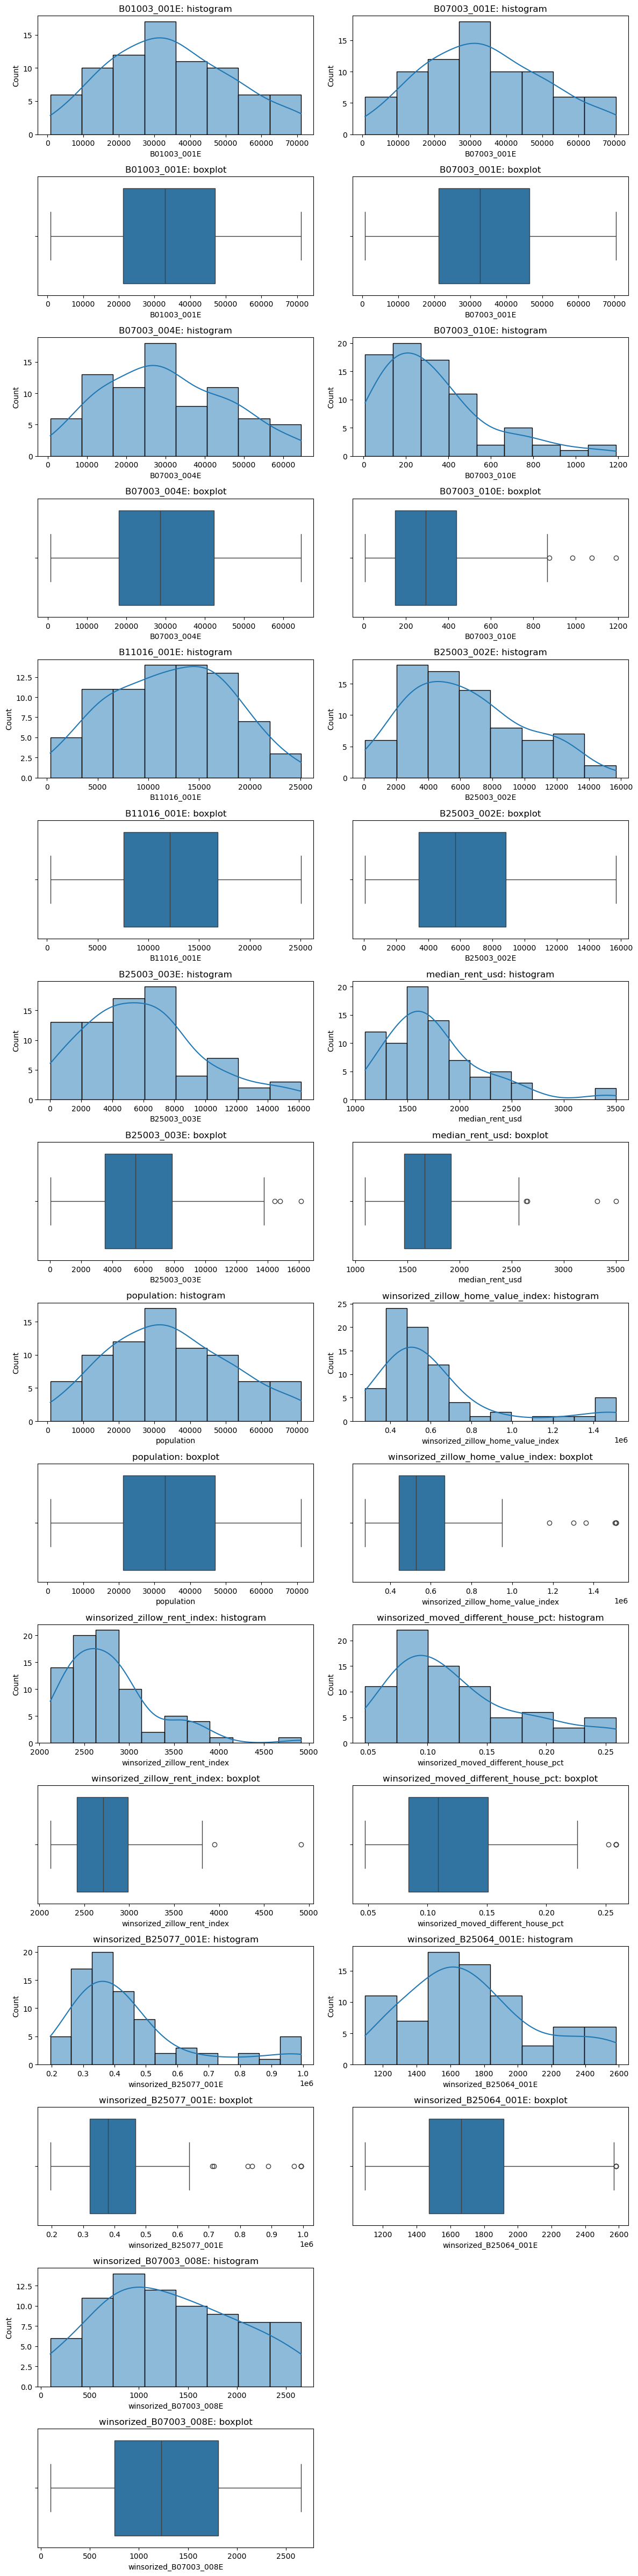

In [55]:
plot_numeric_distributions(
    public_features,
    identifier_columns={'zip'},
)

## 12. Print cleaned results

This cell prints a preview and the shape of every cleaned dataset so we can inspect the transformations, including the extracted numeric fields.

In [51]:
for name, dataset in datasets.items():
    print(f'\n{name}: shape={dataset.shape}')
    display(dataset)


public_features: shape=(78, 16)


,B01003_001E,B07003_001E,B07003_004E,B07003_010E,B11016_001E,B25003_002E,B25003_003E,zip,median_rent_usd,population,winsorized_zillow_home_value_index,winsorized_zillow_rent_index,winsorized_moved_different_house_pct,winsorized_B25077_001E,winsorized_B25064_001E,winsorized_B07003_008E
1,792,792,630,330.881579,328,307,21,33109,NaN,792,1.509148e+06,2833.208483,0.204545,994065.0,1755.233766,97.0
2,1873,1824,962,8.000000,816,76,740,33122,2370.0,1873,1.505538e+06,2740.611111,0.258556,994065.0,2370.000000,241.0
3,54873,54290,49530,171.000000,21227,5080,16147,33125,1238.0,54873,4.597721e+05,2313.579167,0.087677,339300.0,1238.000000,2057.0
4,46798,46403,41635,240.000000,18073,7104,10969,33126,1546.0,46798,3.017829e+05,2380.241026,0.102752,287100.0,1546.000000,1763.0
5,28306,27993,24314,300.000000,9661,2819,6842,33127,1283.0,28306,5.213359e+05,2998.258333,0.131426,346000.0,1283.000000,1533.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,8617,8513,7756,299.000000,1962,1576,386,33194,2363.0,8617,5.709926e+05,2833.208483,0.088923,439500.0,2363.000000,148.0
75,54187,53631,47585,131.000000,16980,11447,5533,33196,2011.0,54187,5.672801e+05,2520.628472,0.112733,428400.0,2011.000000,2209.0
77,31590,31289,28633,300.000000,10281,4939,5342,33054,1244.0,31590,4.207456e+05,2662.500000,0.084886,267300.0,1244.000000,1047.0
78,37977,37702,33945,310.000000,11898,8916,2982,33055,1546.0,37977,5.048859e+05,3080.555556,0.099650,307100.0,1546.000000,1482.0



area_features: shape=(80, 15)


,zip,transit,social,quiet,pet_friendly,walkable,migration_score,median_rent_usd,co_living_friendly,single_family_friendly,rent_band_1200-1800,rent_band_1800-2200,rent_band_2200-2800,rent_band_2800-3500,rent_band_3500+
0,33101,0.000000,0.000000,1.000000,0.6,0.000000,0.000000,NaN,0.150000,0.650000,1,0,0,0,0
1,33109,0.000000,0.011141,0.994429,0.6,0.000000,0.432820,NaN,0.179813,0.650000,1,0,0,0,0
2,33122,0.461831,0.026348,0.986826,0.6,0.999998,1.000000,2370.0,0.415809,0.650000,0,0,1,0,0
3,33125,0.883777,0.771902,0.614049,0.6,0.999997,0.185526,1238.0,0.537352,0.495454,1,0,0,0,0
4,33126,0.707822,0.658311,0.670845,0.6,0.999997,0.217424,1546.0,0.481956,0.557929,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,33196,0.544235,0.762252,0.618874,0.6,0.999998,0.238545,2011.0,0.550000,0.500761,0,1,0,0,0
76,33039,0.000000,0.000000,1.000000,0.6,0.000000,0.000000,NaN,0.150000,0.650000,1,0,0,0,0
77,33054,0.879518,0.444379,0.777811,0.6,0.999997,0.179620,1244.0,0.338475,0.650000,1,0,0,0,0
78,33055,0.707822,0.534225,0.732887,0.6,0.999997,0.210860,1546.0,0.404879,0.626176,1,0,0,0,0



area_options: shape=(10, 16)


,zip,migration_score,median_rent,rent_band_1200-1800,rent_band_1800-2200,rent_band_2200-2800,housing_preference_co_living,housing_preference_own_apartment,household_alone,household_with_co_leaser,tag_co_living,tag_pet_friendly,tag_quiet,tag_social,tag_transit,tag_walkable
0,33127,0.00,1283,1,0,0,0,1,0,1,0,0,0,1,1,1
1,33128,0.00,1191,1,0,0,0,1,0,1,0,0,0,0,1,1
2,33130,0.00,1553,1,0,0,0,1,0,1,0,0,0,1,1,1
3,33127,0.00,1283,1,0,0,0,1,1,0,0,0,0,1,1,1
4,33128,0.00,1191,1,0,0,1,0,1,0,1,0,0,1,1,0
5,33130,0.00,1553,1,0,0,1,0,1,0,1,0,0,1,1,0
6,33132,0.74,2373,0,0,1,0,1,1,0,0,0,0,1,1,1
7,33139,0.53,1680,1,0,0,0,1,1,0,0,0,0,1,1,1
8,33137,0.48,2142,0,1,0,0,1,1,0,0,0,0,1,1,1
9,33133,0.41,1824,0,1,0,0,1,0,1,0,1,1,0,0,0



crowd_text_snippets: shape=(20, 8)


,zip,theme_co_living,theme_expensive,theme_pet_friendly,theme_quiet,theme_single_family,theme_social,theme_transit
0,33127,0,0,0,0,0,0,1
1,33127,0,0,0,0,0,1,0
2,33130,0,0,0,0,0,0,1
3,33130,0,0,0,1,0,0,0
4,33139,0,0,0,0,0,1,0
5,33139,0,1,0,0,0,0,0
6,33133,0,0,0,1,0,0,0
7,33133,0,0,1,0,0,0,0
8,33137,0,0,0,0,0,1,0
9,33142,0,0,0,1,0,0,0


## 13. Check data types across all four datasets

This cell displays the data type of every column after cleaning. It helps confirm that ZIP codes remain strings, numeric columns are numeric, and one-hot encoded columns are integers.

In [52]:
for name, dataset in datasets.items():
    print(f'\n{name} data types:')
    display(dataset.dtypes.to_frame(name='data_type'))


public_features data types:


,data_type
B01003_001E,int64
B07003_001E,int64
B07003_004E,int64
B07003_010E,float64
B11016_001E,int64
B25003_002E,int64
B25003_003E,int64
zip,string[python]
median_rent_usd,float64
population,int64



area_features data types:


,data_type
zip,string[python]
transit,float64
social,float64
quiet,float64
pet_friendly,float64
walkable,float64
migration_score,float64
median_rent_usd,float64
co_living_friendly,float64
single_family_friendly,float64



area_options data types:


,data_type
zip,string[python]
migration_score,float64
median_rent,int64
rent_band_1200-1800,int64
rent_band_1800-2200,int64
rent_band_2200-2800,int64
housing_preference_co_living,int64
housing_preference_own_apartment,int64
household_alone,int64
household_with_co_leaser,int64



crowd_text_snippets data types:


,data_type
zip,string[python]
theme_co_living,int64
theme_expensive,int64
theme_pet_friendly,int64
theme_quiet,int64
theme_single_family,int64
theme_social,int64
theme_transit,int64


# Data Quality check

check all dataset are cleaned

In [53]:
for name, dataset in datasets.items():
    remaining_sentinels = int(dataset.isin(MISSING_VALUES).to_numpy().sum())
    valid_zip = dataset['zip'].notna() & dataset['zip'].str.fullmatch(ZIP_PATTERN).fillna(False)
    duplicate_columns = dataset.columns[dataset.columns.duplicated()].tolist()

    assert remaining_sentinels == 0, f'{name} still contains sentinel values'
    assert valid_zip.all(), f'{name} contains an invalid ZIP code'
    assert not duplicate_columns, f'{name} contains duplicate columns: {duplicate_columns}'

    print(f'{name}: validation passed; rows={len(dataset)}, columns={len(dataset.columns)}')

assert pd.api.types.is_float_dtype(area_options['migration_score'])
assert pd.api.types.is_integer_dtype(area_options['median_rent'])
assert area_options['migration_score'].between(0, 1).all()
assert (area_options['median_rent'] >= 0).all()
print('area_options summary values: validation passed')

public_features: validation passed; rows=78, columns=16
area_features: validation passed; rows=80, columns=15
area_options: validation passed; rows=10, columns=16
crowd_text_snippets: validation passed; rows=20, columns=8
area_options summary values: validation passed


## 12. Run final validation checks

This cell verifies that no configured sentinel values remain, all ZIP values are valid five-digit strings, summary-derived values are numeric and valid, and the cleaned datasets have no duplicate column names.

## 12. Save cleaned datasets

This cell writes each cleaned DataFrame to a new CSV with `_cleaned` in the filename. The original raw datasets are not overwritten.

In [54]:
# output_paths = {}

# for name, dataset in datasets.items():
#     output_path = DATA_DIR / f'{name}_cleaned.csv'
#     dataset.to_csv(output_path, index=False)
#     output_paths[name] = output_path
#     print(f'Saved {name} to {output_path}')